# Spectral Gaussian Fit

Requires 

`w51_irs2_ammonia_maser_positions_CRVAL_CRPIX_change.csv`

In [149]:
import pyspeckit
from spectral_cube import SpectralCube
from astropy import units as u
import pylab as pl
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd

In [150]:
cd /Volumes/GalagaResearch/Developer/masers/W51/FITS/original/

/Volumes/GalagaResearch/Developer/masers/W51/FITS/original


In [151]:
def fit_1d_gaussian(directory, maser_table, x, y, guesses, line, xmin=None, xmax=None, plot=True):

    cube = SpectralCube.read(directory, format='fits')
    cube = cube.with_spectral_unit(u.GHz)

    sp = pyspeckit.Spectrum(xarr=cube.spectral_axis, data=cube[:, y, x])

    sp.specfit(guesses=guesses, linewidth=1.5)
    sp.specfit(guesses=guesses, linewidth=1.5)

    if len(sp.specfit.modelpars) % 3 == 0:
        iters = len(sp.specfit.modelpars) / 3
        for iters in range(int(iters)):
            amplitude = sp.specfit.modelpars[iters * 3]
            freq0 = sp.specfit.modelpars[iters * 3 + 1]
            linewidth = sp.specfit.modelpars[iters * 3 + 2]

        #errors
            amplitude_err = sp.specfit.modelerrs[iters * 3]
            freq0_err = sp.specfit.modelerrs[iters * 3 + 1]
            linewidth_err = sp.specfit.modelerrs[iters * 3 + 2]

            # print(f"Amplitude: {amplitude:.3f} Jy")
            # print(f"Frequency: {freq0:.3f} GHz")
            # print(f"Linewidth: {linewidth:.3f} GHz")   

            new_row = pd.DataFrame({
                'line': [line],
                'x_pix': [x],
                'y_pix': [y],
                'S': [amplitude],
                'freq0': [freq0],
                'linewidth': [linewidth],
                'S_err': [amplitude_err],
                'freq0_err': [freq0_err],
                'linewidth_err': [linewidth_err],
            })

            maser_table = pd.concat([maser_table, new_row], ignore_index=True)   

    if plot:
        fig, ax = pl.subplots(figsize=(12,8))
        # sp.plotter(color='black', xmin=22.92075 * u.GHz, xmax=22.92175 * u.GHz, figure=fig)
        sp.plotter(color='black', xmin=xmin, xmax=xmax, figure=fig)
        sp.specfit.plot_fit(lw=1.0, composite_lw=1.8, show_components=True)

        ax.set_xlabel(f"Frequency [GHz]", fontsize=16)
        #ax.title("NH3 (7,7) Line", fontsize=16)
        ax.set_ylabel(f"$S_\\nu$ (Jy)",fontsize=16)
        pl.yticks(fontsize=16)
        pl.xticks(fontsize=16)
        # pl.text(46, 0.39, "NH$_3$ (7,6)", fontsize = 16)
        plt.title(f"NH3 {line} — Pixel coord. {x, y}", fontsize=16)
        # sp.specfit.plotresiduals(color='black', zeroline=True)
        # pl.ylim(-0.05, 0.05)

    return maser_table

In [152]:
w51_irs2_maser_spectral = pd.DataFrame(columns=['line', 'x_pix', 'y_pix', 'S', 'freq0', 'linewidth', 'S_err', 'freq0_err', 'linewidth_err'])

In [153]:
params = [0.5, 22.92126, 0.00001, 0.3, 22.92115, 0.00001, 0.3, 22.9210, 0.00001]
if len(params) % 3 == 0:
    iters = len(params) / 3
    for iters in range(int(iters)):
        amplitude = params[iters * 3]
        freq0 = params[iters * 3 + 1]
        linewidth = params[iters * 3 + 2]
        print(f"iter {iters}: {amplitude}, {freq0}, {linewidth}")

iter 0: 0.5, 22.92126, 1e-05
iter 1: 0.3, 22.92115, 1e-05
iter 2: 0.3, 22.921, 1e-05


INFO: Left region selection unchanged.  xminpix, xmaxpix: 0,100 [pyspeckit.spectrum.interactive]
INFO: Left region selection unchanged.  xminpix, xmaxpix: 0,100 [pyspeckit.spectrum.interactive]


Cube is a Stokes cube, returning spectral cube for I component
The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
Cube is a Stokes cube, returning spectral cube for I component


INFO: Left region selection unchanged.  xminpix, xmaxpix: 0,100 [pyspeckit.spectrum.interactive]
INFO: Left region selection unchanged.  xminpix, xmaxpix: 0,100 [pyspeckit.spectrum.interactive]


Cube is a Stokes cube, returning spectral cube for I component
Cube is a Stokes cube, returning spectral cube for I component


INFO: Left region selection unchanged.  xminpix, xmaxpix: 0,200 [pyspeckit.spectrum.interactive]
INFO: Left region selection unchanged.  xminpix, xmaxpix: 0,200 [pyspeckit.spectrum.interactive]
INFO: Left region selection unchanged.  xminpix, xmaxpix: 0,200 [pyspeckit.spectrum.interactive]
INFO: Left region selection unchanged.  xminpix, xmaxpix: 0,200 [pyspeckit.spectrum.interactive]


...

INFO: Left region selection unchanged.  xminpix, xmaxpix: 0,200 [pyspeckit.spectrum.interactive]
INFO: Left region selection unchanged.  xminpix, xmaxpix: 0,200 [pyspeckit.spectrum.interactive]


Cube is a Stokes cube, returning spectral cube for I component
Cube is a Stokes cube, returning spectral cube for I component


INFO: Left region selection unchanged.  xminpix, xmaxpix: 0,100 [pyspeckit.spectrum.interactive]
INFO: Left region selection unchanged.  xminpix, xmaxpix: 0,100 [pyspeckit.spectrum.interactive]
INFO: Left region selection unchanged.  xminpix, xmaxpix: 0,100 [pyspeckit.spectrum.interactive]
INFO: Left region selection unchanged.  xminpix, xmaxpix: 0,100 [pyspeckit.spectrum.interactive]


Cube is a Stokes cube, returning spectral cube for I component


INFO: Left region selection unchanged.  xminpix, xmaxpix: 0,200 [pyspeckit.spectrum.interactive]
INFO: Left region selection unchanged.  xminpix, xmaxpix: 0,200 [pyspeckit.spectrum.interactive]


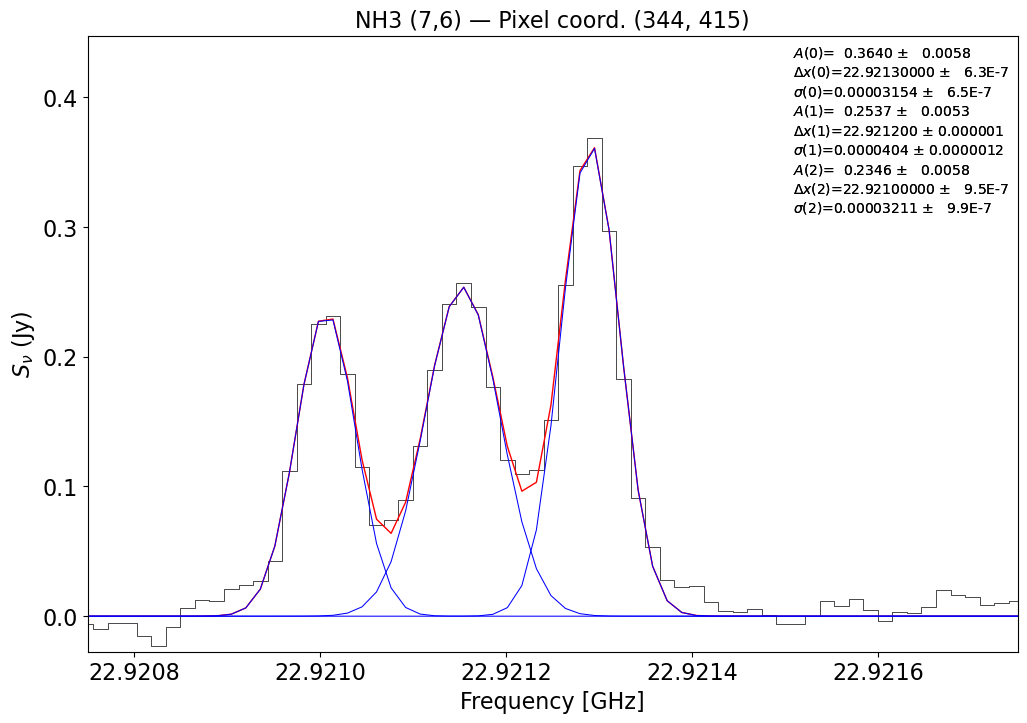

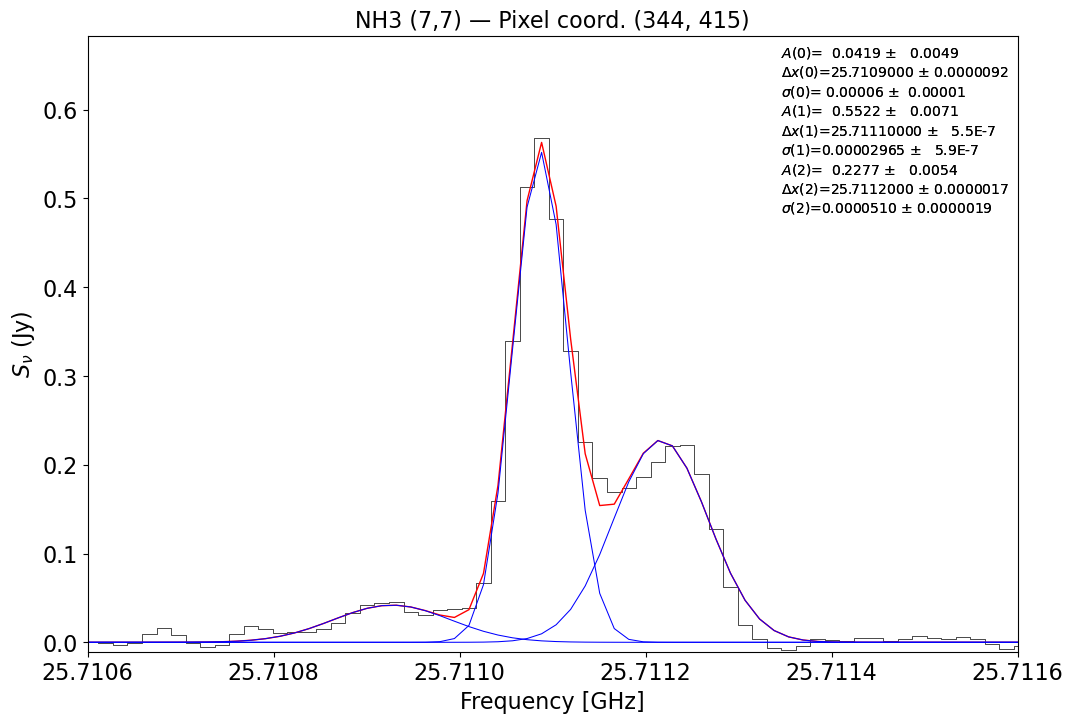

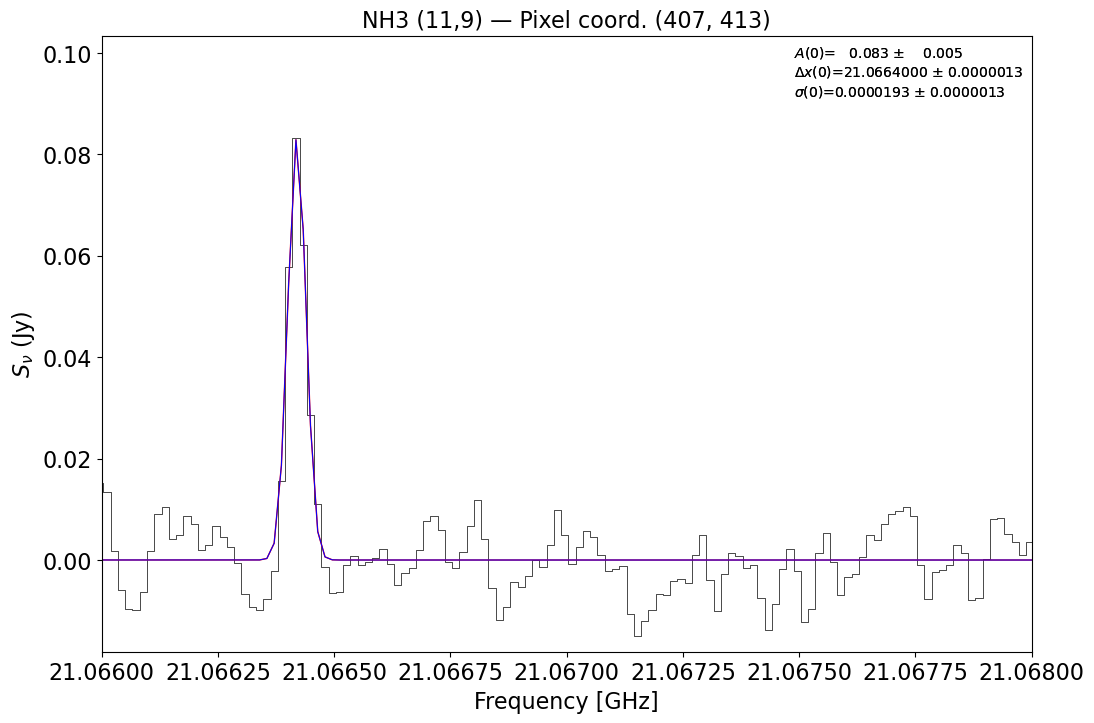

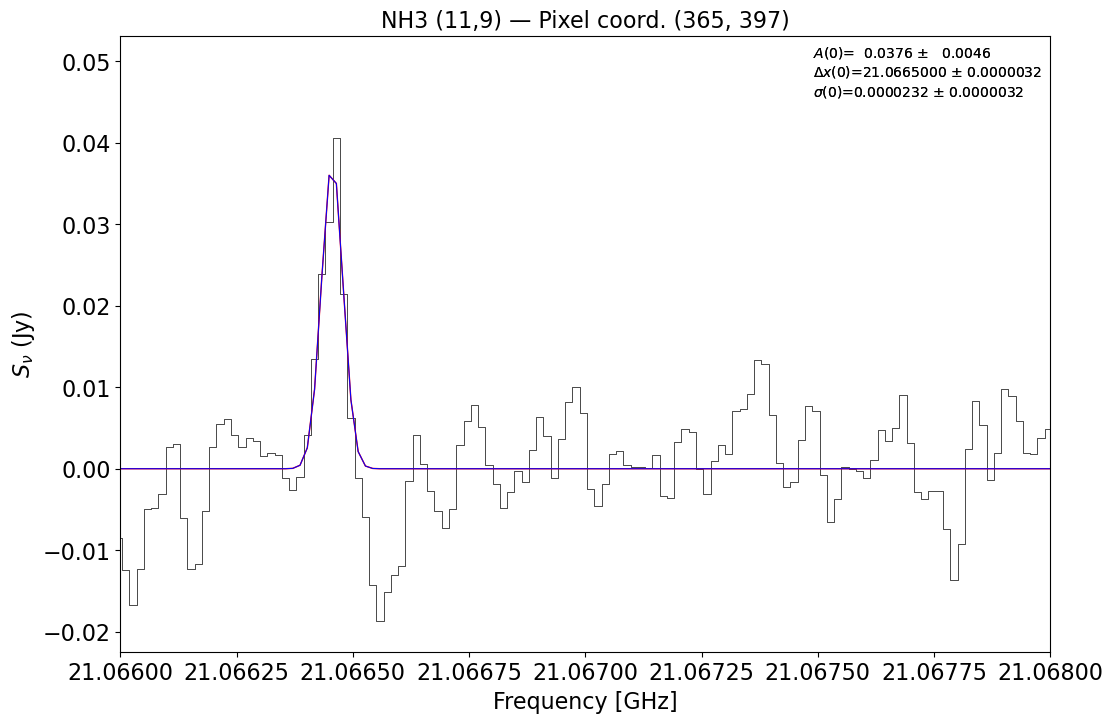

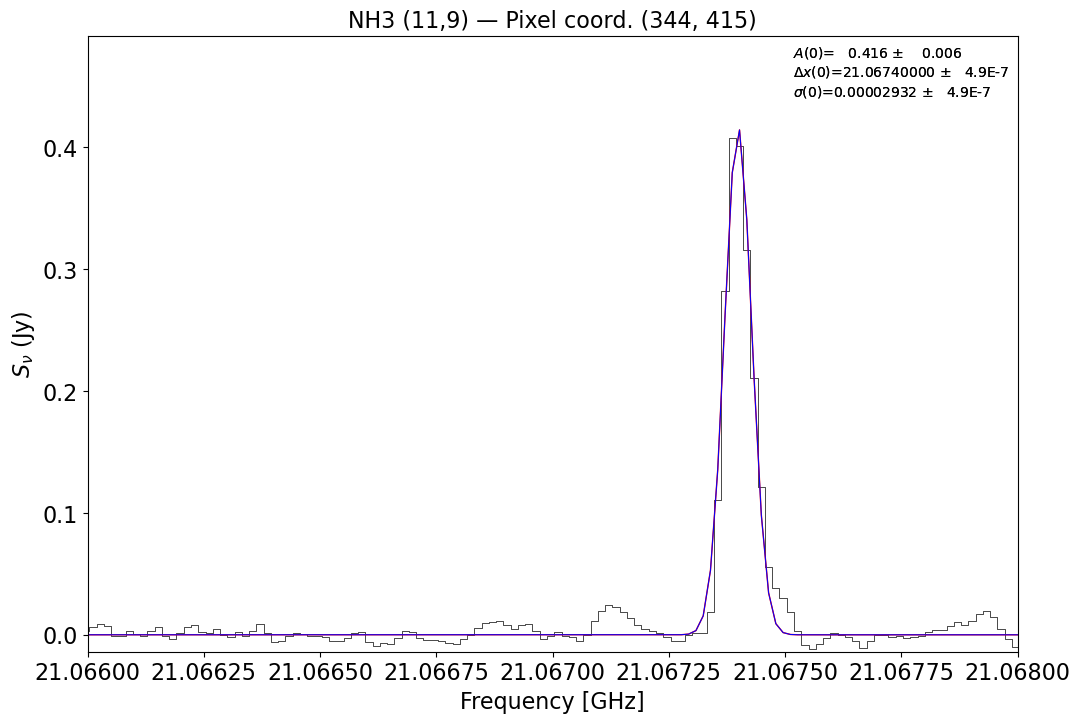

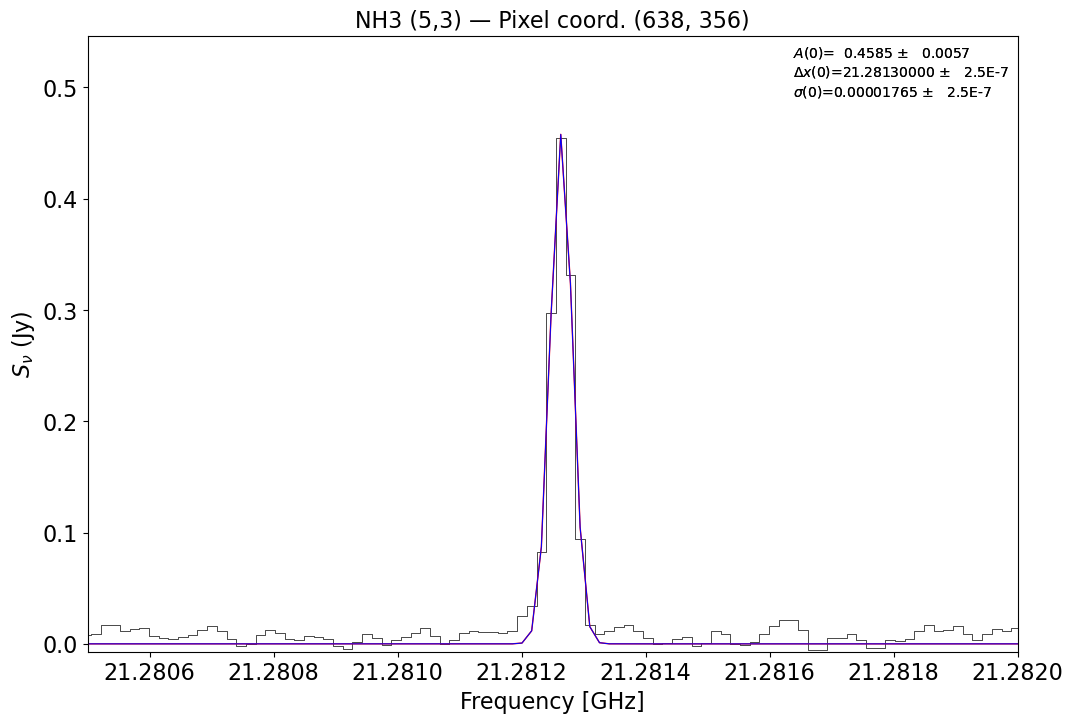

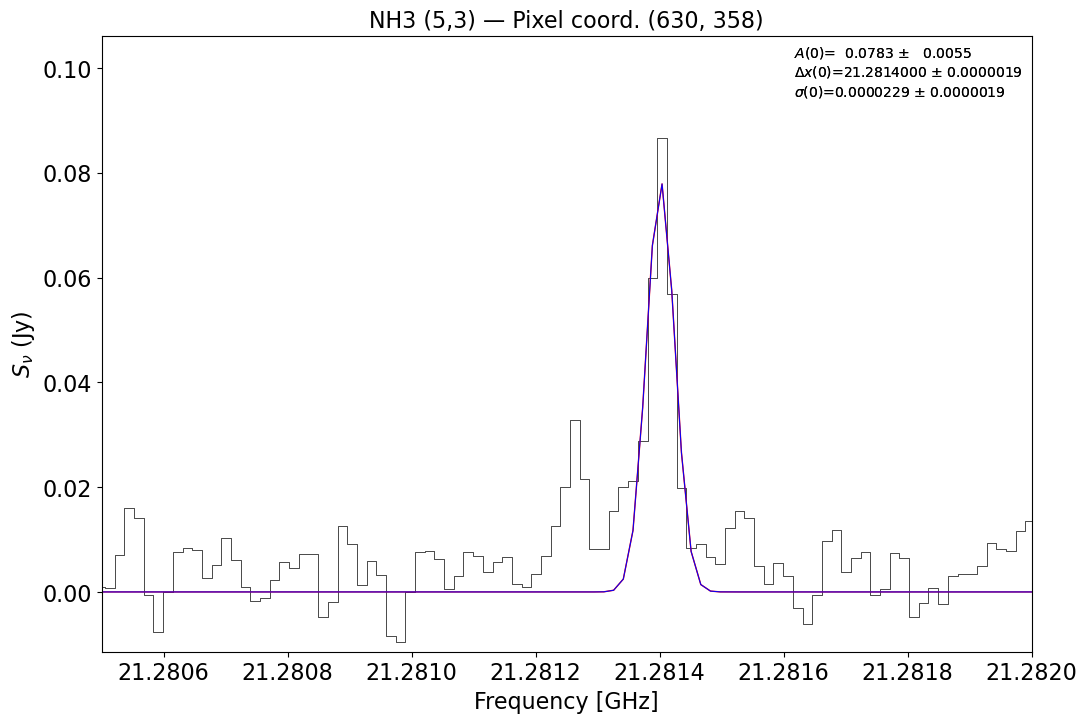

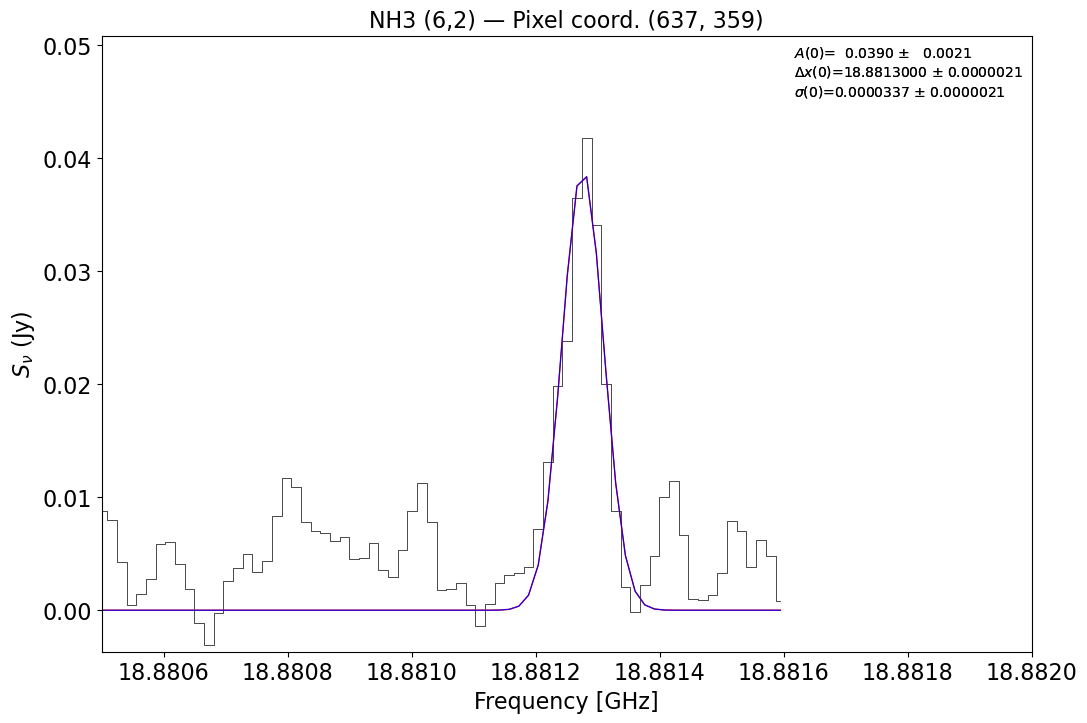

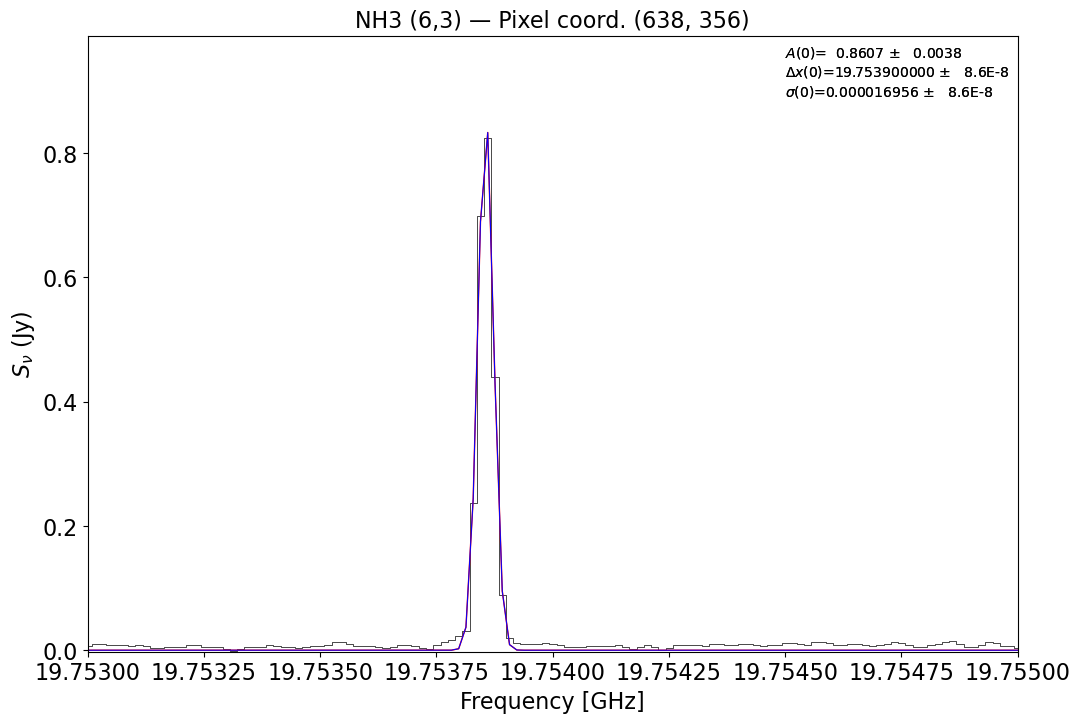

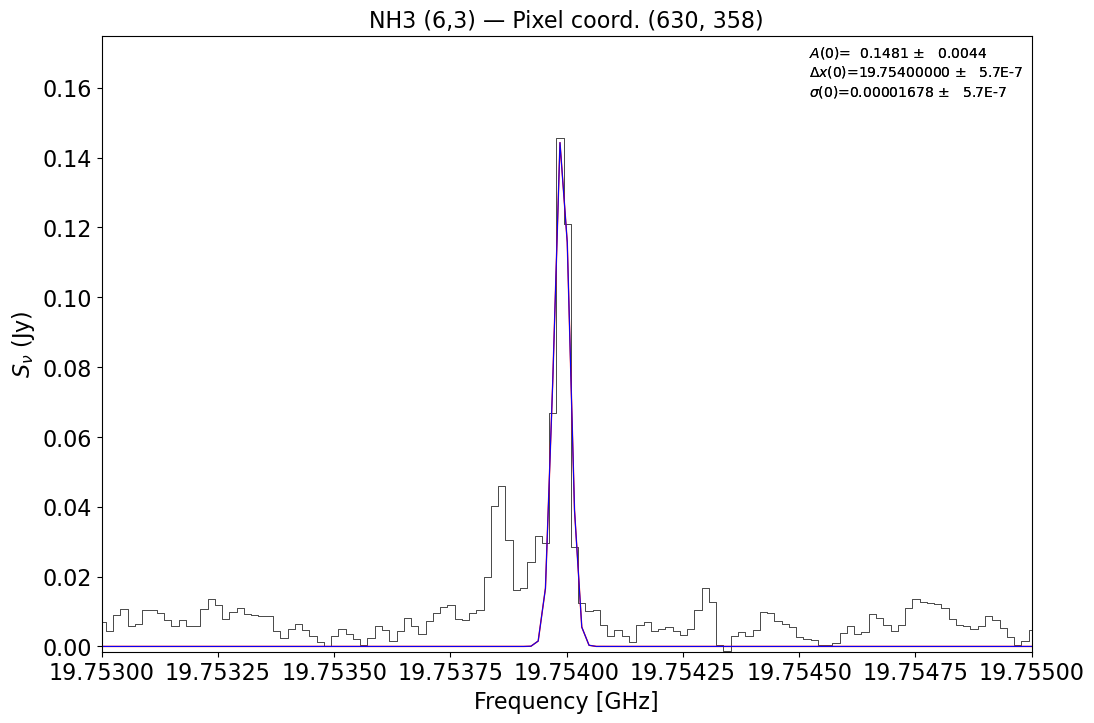

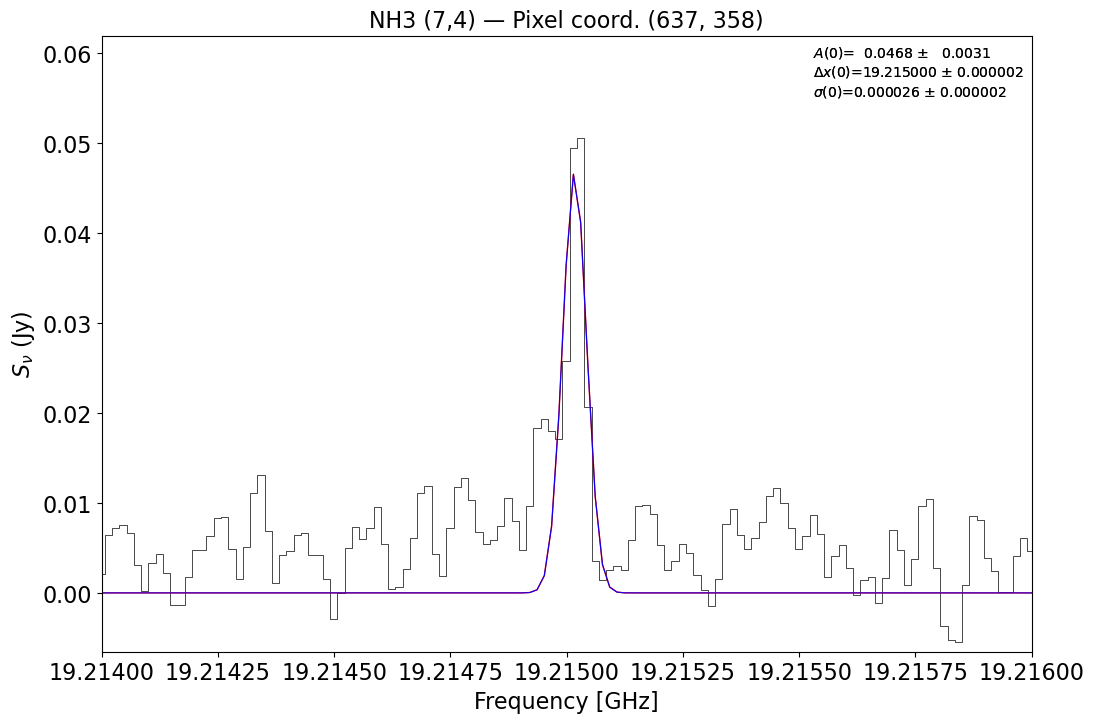

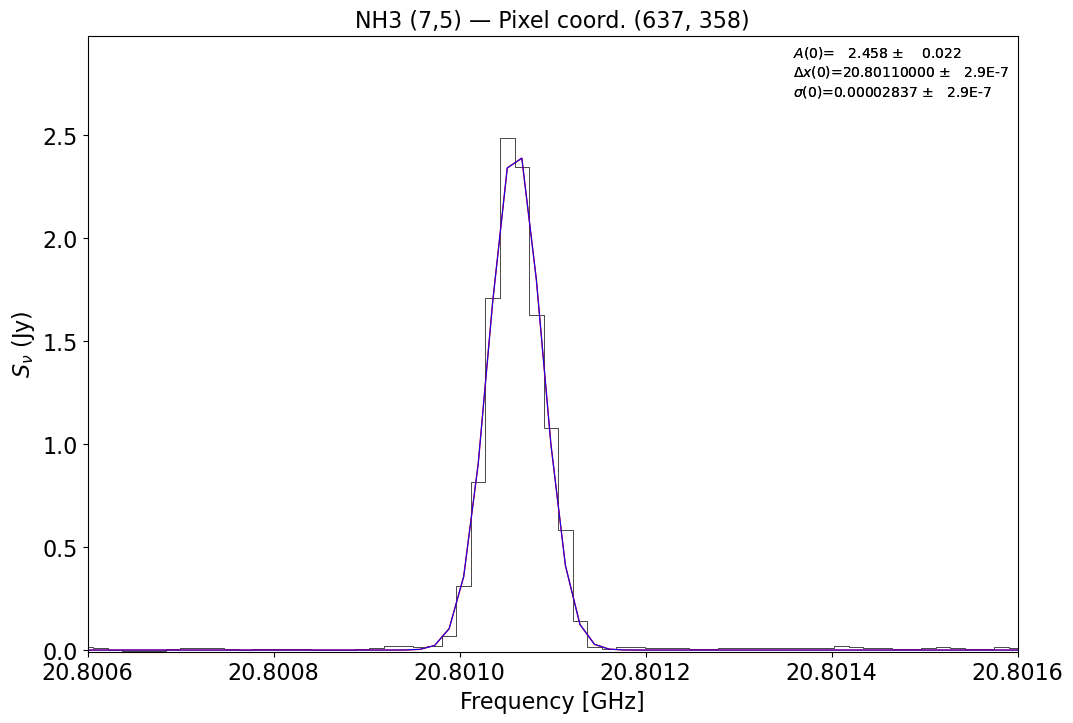

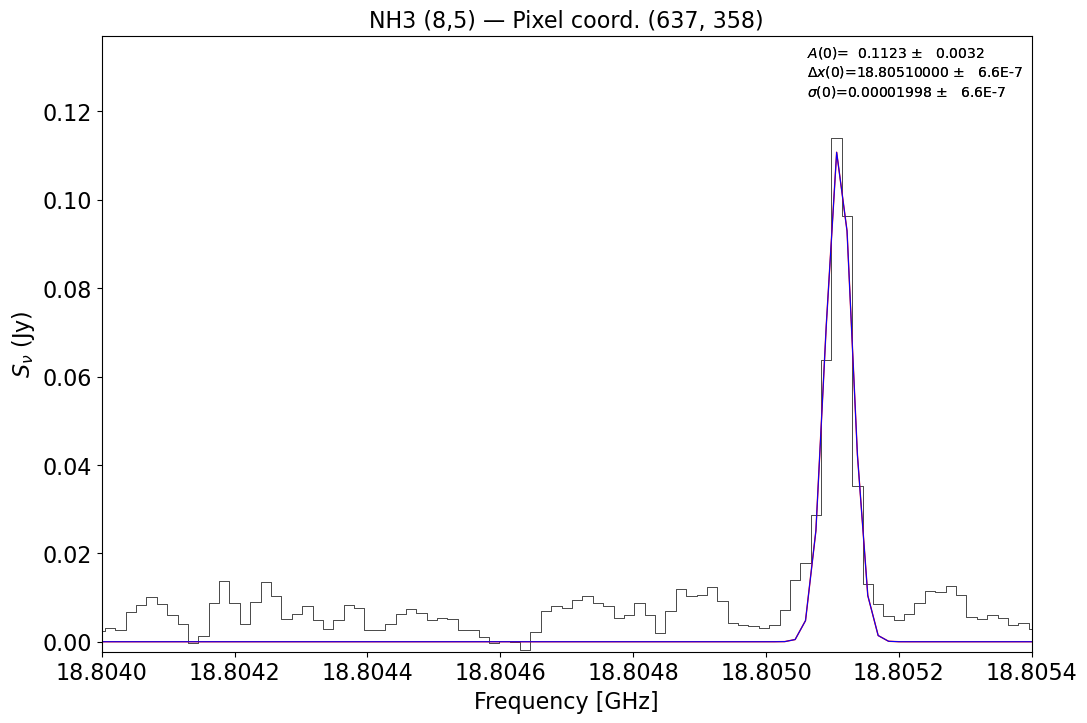

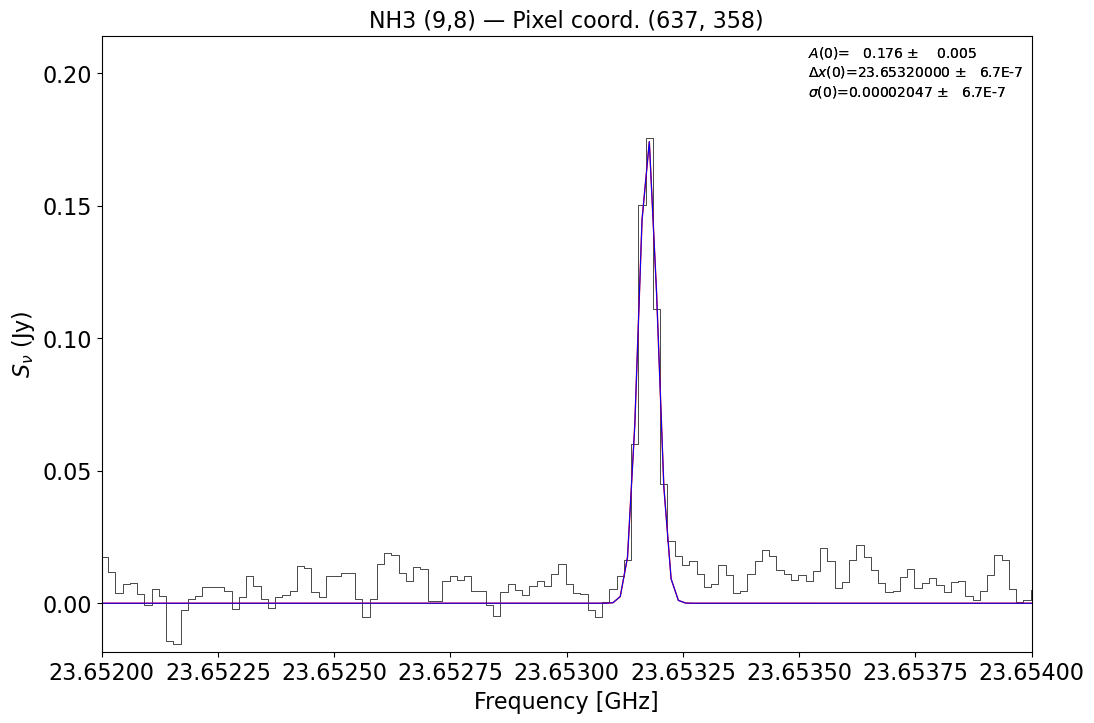

In [154]:
# Fit line (7,6)
w51_irs2_maser_spectral = fit_1d_gaussian(
    directory='W51North_spw_6_corrected50_aug_02_ICRS_CRVAL_CA3_crval_change.fits',
    maser_table=w51_irs2_maser_spectral,
    guesses=[0.5, 22.92126, 0.00001, 0.3, 22.92115, 0.00001, 0.3, 22.9210, 0.00001],
    line='(7,6)', 
    x=344, y=415, 
    xmin=22.92075 * u.GHz,
    xmax=22.92175 * u.GHz,
    plot=True
)

# Fit line (7,7)
w51_irs2_maser_spectral = fit_1d_gaussian(
    directory='W51North_spw_28_corrected40_aug_02_ICRS_CRVAL_CA3_crval_change.fits',
    maser_table=w51_irs2_maser_spectral,
    guesses=[0.1, 25.710947, 0.0001, 0.1, 25.711088, 0.0001, 0.1, 25.711229, 0.0001],
    line='(7,7)', 
    x=344, y=415, 
    xmin=25.7106 * u.GHz,
    xmax=25.7116 * u.GHz,
    plot=True
)

# Fit line (11,9)
w51_irs2_maser_spectral = fit_1d_gaussian(
    directory='W51North_spw_41_corrected2_aug_02_ICRS_CRVAL_CA3_crval_change.fits',
    maser_table=w51_irs2_maser_spectral,
    guesses=[0.08, 21.0664, 0.0001],  # Single component guess; adjust if needed
    line='(11,9)', 
    x=407, y=413, 
    xmin=21.0660 * u.GHz,
    xmax=21.0680 * u.GHz,
    plot=True
)
w51_irs2_maser_spectral = fit_1d_gaussian(
    directory='W51North_spw_41_corrected2_aug_02_ICRS_CRVAL_CA3_crval_change.fits',
    maser_table=w51_irs2_maser_spectral,
    guesses=[0.08, 21.0664, 0.0001],  # Single component guess; adjust if needed
    line='(11,9)', 
    x=365, y=397, 
    xmin=21.0660 * u.GHz,
    xmax=21.0680 * u.GHz,
    plot=True
)
w51_irs2_maser_spectral = fit_1d_gaussian(
    directory='W51North_spw_41_corrected2_aug_02_ICRS_CRVAL_CA3_crval_change.fits',
    maser_table=w51_irs2_maser_spectral,
    guesses=[0.08, 21.0674, 0.0001],  # Single component guess; adjust if needed
    line='(11,9)', 
    x=344, y=415, 
    xmin=21.0660 * u.GHz,
    xmax=21.0680 * u.GHz,
    plot=True
)

# Fit line (5,3)
w51_irs2_maser_spectral = fit_1d_gaussian(
    directory='W51North_spw_44_corrected2_aug_02_ICRS_CRVAL_CA3_crval_change.fits',
    maser_table=w51_irs2_maser_spectral,
    guesses=[0.1, 21.2813, 0.0001],
    line='(5,3)', 
    x=638, y=356, 
    xmin=21.2805 * u.GHz,
    xmax=21.282 * u.GHz,
    plot=True
)
w51_irs2_maser_spectral = fit_1d_gaussian(
    directory='W51North_spw_44_corrected2_aug_02_ICRS_CRVAL_CA3_crval_change.fits',
    maser_table=w51_irs2_maser_spectral,
    guesses=[0.1, 21.2813, 0.0001],
    line='(5,3)', 
    x=630, y=358, 
    xmin=21.2805 * u.GHz,
    xmax=21.282 * u.GHz,
    plot=True
)

# Fit line (6,2)
w51_irs2_maser_spectral = fit_1d_gaussian(
    directory='W51North_spw_50_corrected2_aug_02_ICRS_CRVAL_CA3_crval_change.fits',
    maser_table=w51_irs2_maser_spectral,
    guesses=[0.04, 18.8813, 0.0001],
    line='(6,2)', 
    x=637, y=359, 
    xmin=18.8805 * u.GHz,
    xmax=18.882 * u.GHz,
    plot=True
)

# Fit line (6,3) with multiple components combined (for example, two gaussians)
w51_irs2_maser_spectral = fit_1d_gaussian(
    directory='W51North_spw_56_corrected_40_aug_02_ICRS_CRVAL_CA3_crval_change.fits',
    maser_table=w51_irs2_maser_spectral,
    guesses=[0.93, 19.754, 0.0001],
    line='(6,3)', 
    x=638, y=356, 
    xmin=19.753 * u.GHz,
    xmax=19.755 * u.GHz,
    plot=True
)
w51_irs2_maser_spectral = fit_1d_gaussian(
    directory='W51North_spw_56_corrected_40_aug_02_ICRS_CRVAL_CA3_crval_change.fits',
    maser_table=w51_irs2_maser_spectral,
    guesses=[0.93, 19.754, 0.0001],
    line='(6,3)', 
    x=630, y=358, 
    xmin=19.753 * u.GHz,
    xmax=19.755 * u.GHz,
    plot=True
)

# Fit line (7,4)
w51_irs2_maser_spectral = fit_1d_gaussian(
    directory='W51North_spw_53_corrected2_aug_02_ICRS_CRVAL_CA3_crval_change.fits',
    maser_table=w51_irs2_maser_spectral,
    guesses=[0.05, 19.215, 0.0001],
    line='(7,4)', 
    x=637, y=358, 
    xmin=19.214 * u.GHz,
    xmax=19.216 * u.GHz,
    plot=True
)

# Fit line (7,5)
w51_irs2_maser_spectral = fit_1d_gaussian(
    directory='W51North_spw_38_corrected6_aug_02_ICRS_CRVAL_CA3_crval_change.fits',
    maser_table=w51_irs2_maser_spectral,
    guesses=[0.05, 20.8011, 0.0001],
    line='(7,5)', 
    x=637, y=358, 
    xmin=20.8006 * u.GHz,
    xmax=20.8016 * u.GHz,
    plot=True
)

# Fit line (8,5)
w51_irs2_maser_spectral = fit_1d_gaussian(
    directory='W51North_spw_48_corrected2_aug_02_ICRS_CRVAL_CA3_crval_change.fits',
    maser_table=w51_irs2_maser_spectral,
    guesses=[0.05, 18.8051, 0.0001],
    line='(8,5)', 
    x=637, y=358, 
    xmin=18.804 * u.GHz,
    xmax=18.8054 * u.GHz,
    plot=True
)

# Fit line (9,8)
w51_irs2_maser_spectral = fit_1d_gaussian(
    directory='W51North_spw_8_corrected21_aug_02_ICRS_CRVAL_CA3_crval_change.fits',
    maser_table=w51_irs2_maser_spectral,
    guesses=[0.175, 23.6532, 0.0001],
    line='(9,8)', 
    x=637, y=358, 
    xmin=23.652 * u.GHz,
    xmax=23.654 * u.GHz,
    plot=True
)

In [155]:
w51_irs2_maser_spectral

,line,x_pix,y_pix,S,freq0,linewidth,S_err,freq0_err,linewidth_err
0,"(7,6)",344,415,0.363998,22.921291,0.000032,0.005829,6.262045e-07,6.543783e-07
1,"(7,6)",344,415,0.253679,22.921153,0.000040,0.005314,1.018450e-06,1.187858e-06
2,"(7,6)",344,415,0.234593,22.921006,0.000032,0.005775,9.490850e-07,9.862761e-07
3,"(7,7)",344,415,0.041862,25.710927,0.000063,0.004853,9.174856e-06,1.017921e-05
4,"(7,7)",344,415,0.552206,25.711087,0.000030,0.007140,5.529165e-07,5.878157e-07
5,"(7,7)",344,415,0.227686,25.711217,0.000051,0.005420,1.704628e-06,1.880242e-06
6,"(11,9)",407,413,0.083396,21.066420,0.000019,0.004982,1.329404e-06,1.329248e-06
7,"(11,9)",365,397,0.037612,21.066456,0.000023,0.004565,3.247970e-06,3.247897e-06
8,"(11,9)",344,415,0.416496,21.067399,0.000029,0.005975,4.855923e-07,4.855854e-07
9,"(5,3)",638,356,0.458479,21.281264,0.000018,0.005651,2.513016e-07,2.510602e-07


In [156]:
rest_frequency = {

    '(7,6)' : 22.924940 * u.GHz,
    '(7,7)' : 25.715182 * u.GHz,
    '(11,9)': 21.070739 * u.GHz,
    '(5,3)' : 21.285275 * u.GHz,
    '(6,2)' : 18.884695 * u.GHz,
    '(6,3)' : 19.757538 * u.GHz,
    '(7,4)' : 19.218465 * u.GHz,
    '(7,5)' : 20.804830 * u.GHz,
    '(8,5)' : 18.808507 * u.GHz,
    '(9,8)' : 23.657471 * u.GHz
}

In [157]:
rest_frequency

{'(7,6)': <Quantity 22.92494 GHz>,
 '(7,7)': <Quantity 25.715182 GHz>,
 '(11,9)': <Quantity 21.070739 GHz>,
 '(5,3)': <Quantity 21.285275 GHz>,
 '(6,2)': <Quantity 18.884695 GHz>,
 '(6,3)': <Quantity 19.757538 GHz>,
 '(7,4)': <Quantity 19.218465 GHz>,
 '(7,5)': <Quantity 20.80483 GHz>,
 '(8,5)': <Quantity 18.808507 GHz>,
 '(9,8)': <Quantity 23.657471 GHz>}

In [158]:
c = 299792458

rest_freq_value = []
for i in w51_irs2_maser_spectral['line']:
    rest_freq_value.append(rest_frequency[i].value)
rest_freq_value = np.array(rest_freq_value)

In [159]:
def calc_vlsr(maser_table,):
    # Calculate VLSR from frequency
    
    maser_table['vlsr_ms'] = (rest_freq_value - maser_table['freq0']) / rest_freq_value * c
    maser_table['vlsr_kms'] = maser_table['vlsr_ms'] / 1000 # convert to km/s

    maser_table['vlsr_ms_err'] = (maser_table['freq0_err'] / rest_freq_value) * c
    maser_table['vlsr_kms_err'] = maser_table['vlsr_ms_err'] / 1000 # convert to km/s

    return maser_table

In [160]:
def calc_fwhm(maser_table):

    maser_table['linewidth_ms'] = maser_table['linewidth'] / rest_freq_value * c 
    maser_table['linewidth_kms'] = maser_table['linewidth_ms'] / 1000 # convert to km/s

    maser_table['linewidth_ms_err'] = (maser_table['linewidth_err'] / rest_freq_value) * c
    maser_table['linewidth_kms_err'] = maser_table['linewidth_ms_err'] / 1000 # convert to km/s

    maser_table['fwhm_kms'] = maser_table['linewidth_ms'] * np.sqrt(8 * np.log(2)) / 1000
    maser_table['fwhm_kms_err'] = maser_table['linewidth_ms_err'] * np.sqrt(8 * np.log(2)) / 1000

    return maser_table



In [161]:
calc_vlsr(w51_irs2_maser_spectral)
calc_fwhm(w51_irs2_maser_spectral)

,line,x_pix,y_pix,S,freq0,linewidth,S_err,freq0_err,linewidth_err,vlsr_ms,vlsr_kms,vlsr_ms_err,vlsr_kms_err,linewidth_ms,linewidth_kms,linewidth_ms_err,linewidth_kms_err,fwhm_kms,fwhm_kms_err
0,"(7,6)",344,415,0.363998,22.921291,0.000032,0.005829,6.262045e-07,6.543783e-07,47721.129438,47.721129,8.188959,0.008189,412.408639,0.412409,8.557391,0.008557,0.971148,0.020151
1,"(7,6)",344,415,0.253679,22.921153,0.000040,0.005314,1.018450e-06,1.187858e-06,49521.673335,49.521673,13.318399,0.013318,528.845380,0.528845,15.533781,0.015534,1.245336,0.036579
2,"(7,6)",344,415,0.234593,22.921006,0.000032,0.005775,9.490850e-07,9.862761e-07,51439.704535,51.439705,12.411309,0.012411,419.903392,0.419903,12.897662,0.012898,0.988797,0.030372
3,"(7,7)",344,415,0.041862,25.710927,0.000063,0.004853,9.174856e-06,1.017921e-05,49601.517691,49.601518,106.962212,0.106962,735.183691,0.735184,118.671133,0.118671,1.731225,0.279449
4,"(7,7)",344,415,0.552206,25.711087,0.000030,0.007140,5.529165e-07,5.878157e-07,47739.164066,47.739164,6.446006,0.006446,345.631578,0.345632,6.852866,0.006853,0.813900,0.016137
5,"(7,7)",344,415,0.227686,25.711217,0.000051,0.005420,1.704628e-06,1.880242e-06,46228.968174,46.228968,19.872872,0.019873,594.505180,0.594505,21.920223,0.021920,1.399953,0.051618
6,"(11,9)",407,413,0.083396,21.066420,0.000019,0.004982,1.329404e-06,1.329248e-06,61451.323664,61.451324,18.914633,0.018915,274.212510,0.274213,18.912418,0.018912,0.645721,0.044535
7,"(11,9)",365,397,0.037612,21.066456,0.000023,0.004565,3.247970e-06,3.247897e-06,60939.201999,60.939202,46.211808,0.046212,329.767007,0.329767,46.210763,0.046211,0.776542,0.108818
8,"(11,9)",344,415,0.416496,21.067399,0.000029,0.005975,4.855923e-07,4.855854e-07,47518.035951,47.518036,6.908961,0.006909,417.107271,0.417107,6.908862,0.006909,0.982213,0.016269
9,"(5,3)",638,356,0.458479,21.281264,0.000018,0.005651,2.513016e-07,2.510602e-07,56490.507669,56.490508,3.539457,0.003539,248.599156,0.248599,3.536058,0.003536,0.585406,0.008327


In [162]:
rest_frequency['(7,6)']

<Quantity 22.92494 GHz>

In [163]:
for i in w51_irs2_maser_spectral['line']:
    print(rest_frequency[i])

22.92494 GHz
22.92494 GHz
22.92494 GHz
25.715182 GHz
25.715182 GHz
25.715182 GHz
21.070739 GHz
21.070739 GHz
21.070739 GHz
21.285275 GHz
21.285275 GHz
18.884695 GHz
19.757538 GHz
19.757538 GHz
19.218465 GHz
20.80483 GHz
18.808507 GHz
23.657471 GHz


In [164]:
w51_irs2_maser_positions = pd.read_csv('/Volumes/GalagaResearch/Developer/masers/W51/W51-Masers-and-Starforming-Regions/notebooks/w51_irs2_ammonia_maser_positions_CRVAL_CRPIX_change.csv')

In [ ]:
con

In [173]:
master_w51_irs2_masers = pd.concat([w51_irs2_maser_spectral, w51_irs2_maser_positions], axis=1)

In [178]:
master_w51_irs2_masers.to_csv('/Volumes/GalagaResearch/Developer/masers/W51/W51-Masers-and-Starforming-Regions/notebooks/w51_irs2_ammonia_maser_spectral_spatial_fits.csv', index=False)